# 01 · Visão geral dos resultados

F1 oficial do LoCoMo por categoria e condição, e as três comparações que
estruturam o estudo:

| comparação | isola |
|---|---|
| B3 → G1 | valor das faces (mesmos fatos extraídos) |
| G1 → G2 | valor da curadoria + consolidação |
| G2 → G3 | valor do sigma-agent |

Pré-requisito: `fgl run-all` (ou `fgl run-all --dry-run` + `setup(dry=True)`).


In [1]:
from nbutils import *

# results/ por padrão; use setup(dry=True) para inspecionar um smoke run offline
ctx = setup()
ctx.conditions


✓ 6 condition(s) from C:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\out_experiments\Projeto L\fatgraph-locomo\results: B1-full-context, B2-rag-turns, B3-rag-facts, G1-fatgraph-min, G2-fatgraph-cur, G3-fatgraph-agent


['B1-full-context',
 'B2-rag-turns',
 'B3-rag-facts',
 'G1-fatgraph-min',
 'G2-fatgraph-cur',
 'G3-fatgraph-agent']

## Tabela principal


In [2]:
ctx.f1.pivot_table(index='condition', columns='category', values='f1', observed=True).round(3)


category,multi-hop,temporal,open-domain,single-hop,adversarial
condition,,,,,
B1-full-context,0.005,0.014,0.023,0.01,1.0
B2-rag-turns,0.005,0.014,0.023,0.01,1.0
B3-rag-facts,0.005,0.014,0.023,0.01,1.0
G1-fatgraph-min,0.005,0.014,0.023,0.01,1.0
G2-fatgraph-cur,0.005,0.014,0.023,0.01,1.0
G3-fatgraph-agent,0.005,0.014,0.023,0.01,1.0


In [3]:
ctx.overall.round(3)


,n,f1_micro,f1_macro,abstention_rate,mean_context_tokens
condition,,,,,
B1-full-context,1986,0.233,0.21,1.0,23278.1
B2-rag-turns,1986,0.233,0.21,1.0,421.4
B3-rag-facts,1986,0.233,0.21,1.0,246.3
G1-fatgraph-min,1986,0.233,0.21,1.0,1656.7
G2-fatgraph-cur,1986,0.233,0.21,1.0,1705.5
G3-fatgraph-agent,1986,0.233,0.21,1.0,1649.4


## F1 por categoria


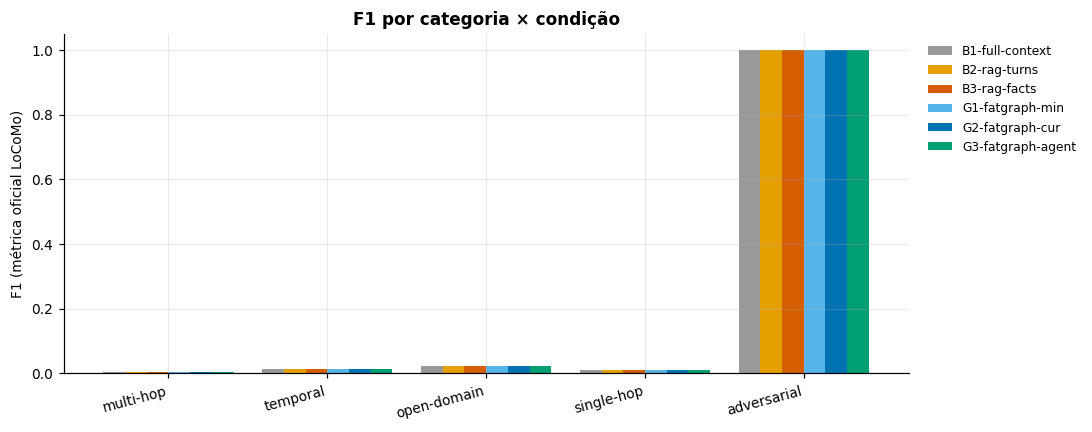

In [4]:
plot_f1_by_category(ctx); show()


## O que cada ingrediente adiciona

Barras acima de zero significam que o ingrediente ajudou naquela categoria.


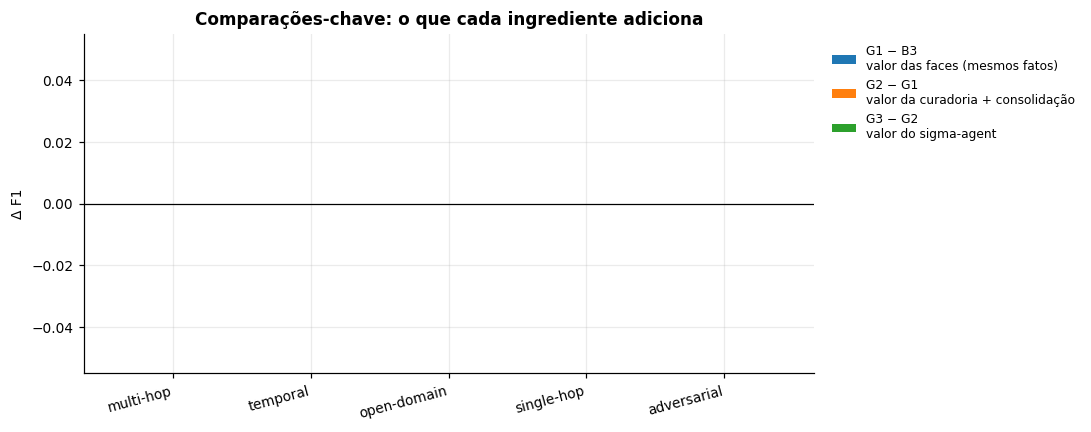

In [5]:
plot_deltas(ctx); show()


## Taxa de abstenção

Em `adversarial` abster-se **é** a resposta certa. Nas demais categorias,
abstenção alta indica que a recuperação não está encontrando a evidência.


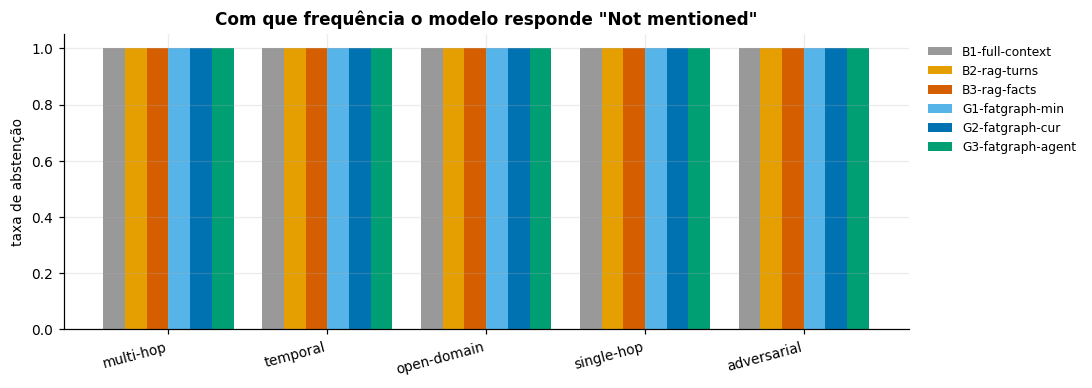

In [6]:
piv = ctx.f1.pivot_table(index='category', columns='condition',
                        values='abstention_rate', observed=True)
ax = piv.plot(kind='bar', figsize=(10, 3.6), color=colors(piv.columns), width=.82)
ax.set_ylabel('taxa de abstenção'); ax.set_xlabel('')
ax.set_title('Com que frequência o modelo responde "Not mentioned"')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right'); show()


## Onde as condições discordam

As perguntas em que uma condição acerta e a outra erra — é aqui que se lê
*qualitativamente* o que a topologia está fazendo.


In [7]:
preds = ctx.all_predictions()
if preds.empty:
    print('sem predictions.jsonl')
else:
    a, b = 'B3-rag-facts', 'G1-fatgraph-min'
    have = set(preds.condition.unique())
    if {a, b} <= have:
        key = ['question', 'category_name', 'gold']
        A = preds[preds.condition == a].set_index(key)
        B = preds[preds.condition == b].set_index(key)
        join = A[['prediction', 'f1']].join(
            B[['prediction', 'f1']], lsuffix=f'_{a}', rsuffix=f'_{b}', how='inner')
        join['delta'] = join[f'f1_{b}'] - join[f'f1_{a}']
        display(join.sort_values('delta', ascending=False).head(10))
        display(join.sort_values('delta').head(10))
    else:
        print(f'preciso de {a} e {b}; tenho {sorted(have)}')


,,,prediction_B3-rag-facts,f1_B3-rag-facts,prediction_G1-fatgraph-min,f1_G1-fatgraph-min,delta
question,category_name,gold,,,,,
Where did Calvin take a stunning photo of a waterfall?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
When did Caroline go to the LGBTQ support group?,temporal,7 May 2023,Not mentioned in the conversation,0.0,Not mentioned in the conversation,0.0,0.0
When did Melanie paint a sunrise?,temporal,2022,Not mentioned in the conversation,0.0,Not mentioned in the conversation,0.0,0.0
What fields would Caroline be likely to pursue in her educaton?,open-domain,"Psychology, counseling certification",Not mentioned in the conversation,0.0,Not mentioned in the conversation,0.0,0.0
What did Caroline research?,multi-hop,Adoption agencies,Not mentioned in the conversation,0.0,Not mentioned in the conversation,0.0,0.0
What is Caroline's identity?,multi-hop,Transgender woman,Not mentioned in the conversation,0.0,Not mentioned in the conversation,0.0,0.0
When did Melanie run a charity race?,temporal,The sunday before 25 May 2023,Not mentioned in the conversation,0.0,Not mentioned in the conversation,0.0,0.0
When is Melanie planning on going camping?,temporal,June 2023,Not mentioned in the conversation,0.0,Not mentioned in the conversation,0.0,0.0
Who headlined the music festival that Calvin attended in October?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0


,,,prediction_B3-rag-facts,f1_B3-rag-facts,prediction_G1-fatgraph-min,f1_G1-fatgraph-min,delta
question,category_name,gold,,,,,
What type of videos does Dave usually watch on his television?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
What did Calvin recently start a blog about?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
What did Dave do recently at his Japanese house?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
What realization did the nightclub experience bring to Dave?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
When did Calvin first get interested in motorcycles?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
When did Calvin sell the car he restored last year?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
What specific location in Tokyo does Calvin mention being excited to avoid?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
Which part of Tokyo is described as Tokyo's Times Square by Dave?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0
Who headlined the music festival that Calvin attended in October?,adversarial,Not mentioned in the conversation,Not mentioned in the conversation,1.0,Not mentioned in the conversation,1.0,0.0


## Relatório completo em Markdown

Idêntico ao que `fgl report` imprime — mesma função, mesmos números.


In [8]:
print(ctx.report())


# Resultados — memória fatgraph no LoCoMo

F1 é a métrica oficial do LoCoMo (token-level, `task_eval/evaluation.py`), reportada para **todas** as categorias, inclusive adversarial. Nada foi filtrado nem subamostrado.

## F1 por categoria

| condition | multi-hop | temporal | open-domain | single-hop | adversarial | macro | micro |
|---|---|---|---|---|---|---|---|
| B1-full-context | 0.005 | 0.014 | 0.023 | 0.010 | 1.000 | 0.210 | 0.233 |
| B2-rag-turns | 0.005 | 0.014 | 0.023 | 0.010 | 1.000 | 0.210 | 0.233 |
| B3-rag-facts | 0.005 | 0.014 | 0.023 | 0.010 | 1.000 | 0.210 | 0.233 |
| G1-fatgraph-min | 0.005 | 0.014 | 0.023 | 0.010 | 1.000 | 0.210 | 0.233 |
| G2-fatgraph-cur | 0.005 | 0.014 | 0.023 | 0.010 | 1.000 | 0.210 | 0.233 |
| G3-fatgraph-agent | 0.005 | 0.014 | 0.023 | 0.010 | 1.000 | 0.210 | 0.233 |

## Comparações-chave

| comparação | isola | F1 base | F1 novo | Δ | Δ% |
|---|---|---|---|---|---|
| G1-fatgraph-min − B3-rag-facts | valor das faces (mesmos fatos) | 0.233 | 0.23